# Pipeline 2: Resident Reintegration Readiness

## Problem Framing

**Business Question:** Which residents are on track for successful reintegration, and what factors are most associated with risk level improvement?

**Unit of Analysis:** One row per resident (N=60).

**Target Variable — Predictive:** Binary `reintegration_completed` — 1 if `reintegration_status == 'Completed'`. Expected: 19 completed, 41 not (class imbalance — use stratified split, report F1 alongside accuracy).

**Target Variable — Explanatory:** Binary `risk_improved` — 1 if `current_risk_level` is lower than `initial_risk_level` (ordinal: Low=1, Medium=2, High=3, Critical=4).

**Predictive Goal:** Reintegration readiness score for each active resident. Optimize Recall. Compare logistic regression, decision tree, random forest.

**Explanatory Goal:** Logistic regression on `risk_improved`. Which factors are most associated with risk reduction? Report odds ratios with confidence intervals. All language is associative — this is observational data.

**Leakage Declarations:**
- EXCLUDED: `Post-Placement Monitoring` and `Reintegration Assessment` home visit types — these only occur after reintegration is underway
- EXCLUDED: `reintegration_type`, `date_closed` — determined alongside or after the outcome
- EXCLUDED: `case_status` — directly encodes case progression

**⚠️ Reverse causality note:** Residents with higher session counts and visit counts may appear more likely to complete reintegration simply because they had longer program tenure, not because counseling caused better outcomes. This is flagged explicitly below.

**Validation:** N=60, 19 positives. Use stratified 5-fold CV throughout.

This model does two things. First, it gives each resident a reintegration readiness score, which helps staff spot who may need more support. Second, it shows which factors are linked to risk improvement. In your results, prediction accuracy is moderate, so this is best used as a screening tool, not a final decision by itself. The strongest pattern is that residents who start at higher risk are more likely to show improvement, and better home visit outcomes also look helpful, while many other effects are less certain. These are associations, not proof of cause-and-effect, and longer stay in the program can make some support variables look stronger than they really are.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
import statsmodels.api as sm
from scipy import stats
import re
import os
import pickle

# Keep all outputs inside this notebook (no external image/model files)
def _disable_external_artifacts():
    plt.savefig = lambda *args, **kwargs: None
    def _blocked_pickle_dump(*args, **kwargs):
        raise RuntimeError('External .pkl exports are disabled. Keep artifacts in-notebook only.')
    pickle.dump = _blocked_pickle_dump

_disable_external_artifacts()

# Clean up old exported artifacts if they exist
for _artifact in [
    '/Users/marycatherineshepherd/Documents/INTEX II/ml_pipelines/p2_eda.png',
    '/Users/marycatherineshepherd/Documents/INTEX II/ml_pipelines/p2_feat_imp.png',
    '/Users/marycatherineshepherd/Documents/INTEX II/ml_pipelines/p2_odds_ratios.png',
    '/Users/marycatherineshepherd/Documents/INTEX II/ml_pipelines/p2_readiness_model.pkl',
]:
    if os.path.exists(_artifact):
        os.remove(_artifact)

from pathlib import Path
import os

def _resolve_data_path():
    env_path = os.getenv('LIGHTHOUSE_DATA_PATH')
    if env_path and Path(env_path).exists():
        return Path(env_path)

    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        candidate = base / 'lighthouse_csv_v7'
        if candidate.exists():
            return candidate

    fallback = Path('/Users/marycatherineshepherd/Documents/lighthouse_csv_v7')
    if fallback.exists():
        return fallback

    raise FileNotFoundError(
        "Could not locate 'lighthouse_csv_v7'. Set LIGHTHOUSE_DATA_PATH or place the folder in project/parent directories."
    )

DATA_PATH = str(_resolve_data_path()) + '/'


def _safe_read_csv(filename, parse_dates=None, required_cols=None, default_map=None):
    df = pd.read_csv(DATA_PATH + filename)
    required_cols = required_cols or []
    default_map = default_map or {}

    missing_cols = []
    for c in required_cols:
        if c not in df.columns:
            df[c] = default_map.get(c, np.nan)
            missing_cols.append(c)

    for c, v in default_map.items():
        if c in df.columns:
            df[c] = df[c].fillna(v)

    missing_date_cols = []
    if parse_dates:
        for c in parse_dates:
            if c in df.columns:
                df[c] = pd.to_datetime(df[c], errors='coerce')
            else:
                missing_date_cols.append(c)

    if missing_cols:
        print(f"[Schema] {filename}: added missing columns -> {missing_cols}")
    if missing_date_cols:
        print(f"[Schema] {filename}: skipped missing date columns -> {missing_date_cols}")

    return df
# Load all required tables (dynamic-safe)
residents = _safe_read_csv(
    'residents.csv',
    parse_dates=['date_of_admission','date_closed','date_enrolled'],
    required_cols=['resident_id','safehouse_id','initial_risk_level','current_risk_level','reintegration_status','case_status']
)
process_rec = _safe_read_csv(
    'process_recordings.csv',
    parse_dates=['session_date'],
    required_cols=['resident_id','session_date','session_duration_minutes','progress_noted','concerns_flagged','emotional_state_observed','emotional_state_end']
)
education = _safe_read_csv(
    'education_records.csv',
    parse_dates=['record_date'],
    required_cols=['resident_id','record_date','attendance_rate','progress_percent']
)
health = _safe_read_csv(
    'health_wellbeing_records.csv',
    parse_dates=['record_date'],
    required_cols=['resident_id','record_date','general_health_score']
)
visitations = _safe_read_csv(
    'home_visitations.csv',
    parse_dates=['visit_date'],
    required_cols=['resident_id','visit_date','visit_type','family_cooperation_level','visit_outcome']
)
incidents = _safe_read_csv(
    'incident_reports.csv',
    parse_dates=['incident_date'],
    required_cols=['resident_id','incident_date','incident_type','severity']
)
plans = _safe_read_csv(
    'intervention_plans.csv',
    required_cols=['resident_id','status']
)

print('Data loaded.')
for name, frame in [('residents', residents), ('process_rec', process_rec),
                     ('education', education), ('health', health),
                     ('visitations', visitations), ('incidents', incidents), ('plans', plans)]:
    print(f'  {name}: {frame.shape}')


# --- Data Cleaning Audit (Thoroughness Report) ---
def _cleaning_audit(df_map):
    rows = []
    for name, frame in df_map.items():
        miss = int(frame.isna().sum().sum())
        miss_pct = float((frame.isna().mean().mean() * 100) if len(frame.columns) else 0)
        rows.append({
            'table': name,
            'rows': int(len(frame)),
            'cols': int(frame.shape[1]),
            'total_missing_cells': miss,
            'avg_missing_pct_across_cols': round(miss_pct, 2)
        })
    rep = pd.DataFrame(rows).sort_values('table')
    print(rep)
    return rep


Data loaded.
  residents: (60, 49)
  process_rec: (2819, 15)
  education: (534, 10)
  health: (534, 14)
  visitations: (1337, 14)
  incidents: (100, 12)
  plans: (180, 11)


In [2]:
# --- Target Variables ---
RISK_MAP = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}

df = residents.copy()

# Target 1: reintegration_completed
df['reintegration_completed'] = (df['reintegration_status'] == 'Completed').astype(int)
print(f'Reintegration completed:\n{df["reintegration_completed"].value_counts()}')

# Target 2: risk_improved
df['initial_risk_ordinal'] = df['initial_risk_level'].map(RISK_MAP)
df['current_risk_ordinal'] = df['current_risk_level'].map(RISK_MAP)
df['risk_improved'] = (df['current_risk_ordinal'] < df['initial_risk_ordinal']).astype(int)
print(f'\nRisk improved:\n{df["risk_improved"].value_counts()}')

Reintegration completed:
reintegration_completed
0    41
1    19
Name: count, dtype: int64

Risk improved:
risk_improved
0    32
1    28
Name: count, dtype: int64


In [3]:
CLEANING_AUDIT = _cleaning_audit({'residents': residents, 'process_rec': process_rec, 'education': education, 'health': health, 'visitations': visitations, 'incidents': incidents, 'plans': plans})


         table  rows  cols  total_missing_cells  avg_missing_pct_across_cols
2    education   534    10                    0                         0.00
3       health   534    14                    0                         0.00
5    incidents   100    12                   29                         2.42
6        plans   180    11                   48                         2.42
1  process_rec  2819    15                 2819                         6.67
0    residents    60    49                  278                         9.46
4  visitations  1337    14                  974                         5.20


In [4]:
# --- Feature Engineering: Resident-Level ---

# 1. num_trauma_categories
sub_cat_cols = [c for c in df.columns if c.startswith('sub_cat_')]
df['num_trauma_categories'] = df[sub_cat_cols].apply(
    lambda row: sum(str(v).strip().lower() in ('true', '1') for v in row), axis=1
)

# 2. family_vulnerability_score
family_cols = ['family_is_4ps', 'family_solo_parent', 'family_indigenous', 
               'family_parent_pwd', 'family_informal_settler']
df['family_vulnerability_score'] = df[family_cols].apply(
    lambda row: sum(str(v).strip().lower() in ('true', '1') for v in row), axis=1
)

# 3. age_at_admission_years — parse from string like "15 Years 9 months"
def parse_age_years(age_str):
    if pd.isna(age_str):
        return np.nan
    match = re.search(r'(\d+)\s*[Yy]ear', str(age_str))
    months_match = re.search(r'(\d+)\s*[Mm]onth', str(age_str))
    years = int(match.group(1)) if match else 0
    months = int(months_match.group(1)) if months_match else 0
    return years + months / 12

df['age_at_admission_years'] = df['age_upon_admission'].apply(parse_age_years)

# 4. length_of_stay_days — parse from string like "2 Years 4 months"
def parse_stay_days(stay_str):
    if pd.isna(stay_str):
        return np.nan
    years = 0
    months = 0
    y_match = re.search(r'(\d+)\s*[Yy]ear', str(stay_str))
    m_match = re.search(r'(\d+)\s*[Mm]onth', str(stay_str))
    if y_match:
        years = int(y_match.group(1))
    if m_match:
        months = int(m_match.group(1))
    return years * 365 + months * 30

df['length_of_stay_days'] = df['length_of_stay'].apply(parse_stay_days)

# 5. has_special_needs
df['has_special_needs_int'] = df['has_special_needs'].apply(
    lambda x: 1 if str(x).strip().lower() in ('true', '1') else 0
)

# 6. trauma x special_needs interaction
df['trauma_x_special_needs'] = df['num_trauma_categories'] * df['has_special_needs_int']

# 7. initial_risk_level_ordinal (already computed above)
df['initial_risk_level_ordinal'] = df['initial_risk_ordinal']

print('Resident features engineered.')
print(df[['resident_id','num_trauma_categories','family_vulnerability_score',
          'age_at_admission_years','length_of_stay_days','has_special_needs_int']].head())

Resident features engineered.
   resident_id  num_trauma_categories  family_vulnerability_score  \
0            1                      0                           0   
1            2                      2                           1   
2            3                      1                           0   
3            4                      1                           0   
4            5                      2                           1   

   age_at_admission_years  length_of_stay_days  has_special_needs_int  
0               15.750000                  850                      1  
1               15.416667                  635                      0  
2               18.250000                  635                      0  
3               12.916667                  515                      0  
4               15.333333                  270                      0  


In [5]:
# --- Feature Engineering: Counseling Sessions ---
EMOTION_MAP = {'Distressed':1,'Angry':2,'Withdrawn':3,'Sad':4,
               'Anxious':5,'Calm':6,'Hopeful':7,'Happy':8}

process_rec['emotion_start_num'] = process_rec['emotional_state_observed'].map(EMOTION_MAP)
process_rec['emotion_end_num'] = process_rec['emotional_state_end'].map(EMOTION_MAP)
process_rec['emotional_lift'] = process_rec['emotion_end_num'] - process_rec['emotion_start_num']

def counseling_features(group):
    group = group.sort_values('session_date')
    n = len(group)
    if n == 0:
        return pd.Series({'total_counseling_sessions': 0, 'avg_session_duration_minutes': np.nan,
                          'pct_sessions_progress_noted': 0, 'pct_sessions_concerns_flagged': 0,
                          'avg_emotional_lift': np.nan, 'emotional_trend_slope': np.nan,
                          'session_gap_std_dev': np.nan})
    
    # Gap std dev
    if n > 1:
        gaps = group['session_date'].diff().dt.days.dropna()
        gap_std = gaps.std()
    else:
        gap_std = np.nan
    
    # Emotional trend slope
    end_emotions = group['emotion_end_num'].dropna()
    if len(end_emotions) >= 2:
        x = np.arange(len(end_emotions))
        slope, _, _, _, _ = stats.linregress(x, end_emotions)
    else:
        slope = np.nan
    
    return pd.Series({
        'total_counseling_sessions': n,
        'avg_session_duration_minutes': group['session_duration_minutes'].mean(),
        'pct_sessions_progress_noted': group['progress_noted'].apply(
            lambda x: 1 if str(x).lower() in ('true','1') else 0).mean(),
        'pct_sessions_concerns_flagged': group['concerns_flagged'].apply(
            lambda x: 1 if str(x).lower() in ('true','1') else 0).mean(),
        'avg_emotional_lift': group['emotional_lift'].mean(),
        'emotional_trend_slope': slope,
        'session_gap_std_dev': gap_std
    })

counsel_feats = process_rec.groupby('resident_id').apply(counseling_features).reset_index()
df = df.merge(counsel_feats, on='resident_id', how='left')
df['total_counseling_sessions'] = df['total_counseling_sessions'].fillna(0)
print('Counseling features done.')

Counseling features done.


In [6]:
# --- Feature Engineering: Education ---
def education_features(group):
    group = group.sort_values('record_date')
    n = len(group)
    if n == 0:
        return pd.Series({'avg_attendance_rate': np.nan, 'avg_progress_pct': np.nan,
                          'education_progress_slope': np.nan})
    
    progress = group['progress_percent'].dropna()
    if len(progress) >= 2:
        x = np.arange(len(progress))
        slope, _, _, _, _ = stats.linregress(x, progress)
    else:
        slope = np.nan
    
    return pd.Series({
        'avg_attendance_rate': group['attendance_rate'].mean(),
        'avg_progress_pct': group['progress_percent'].mean(),
        'education_progress_slope': slope
    })

edu_feats = education.groupby('resident_id').apply(education_features).reset_index()
df = df.merge(edu_feats, on='resident_id', how='left')

# --- Feature Engineering: Health ---
def health_features(group):
    group = group.sort_values('record_date')
    scores = group['general_health_score'].dropna()
    if len(scores) >= 2:
        x = np.arange(len(scores))
        slope, _, _, _, _ = stats.linregress(x, scores)
    else:
        slope = np.nan
    return pd.Series({
        'avg_general_health_score': scores.mean() if len(scores) > 0 else np.nan,
        'health_trend_slope': slope
    })

health_feats = health.groupby('resident_id').apply(health_features).reset_index()
df = df.merge(health_feats, on='resident_id', how='left')
print('Education and health features done.')

Education and health features done.


In [7]:
# --- Feature Engineering: Home Visitations ---
# CRITICAL: Exclude Post-Placement Monitoring and Reintegration Assessment visit types
ALLOWED_VISIT_TYPES = ['Initial Assessment', 'Routine Follow-Up']
visits_filtered = visitations[visitations['visit_type'].isin(ALLOWED_VISIT_TYPES)].copy()

COOPERATION_MAP = {'Uncooperative': 1, 'Neutral': 2, 'Cooperative': 3, 'Highly Cooperative': 4}
visits_filtered['cooperation_num'] = visits_filtered['family_cooperation_level'].map(COOPERATION_MAP)

def visit_features(group):
    group = group.sort_values('visit_date')
    n = len(group)
    if n == 0:
        return pd.Series({'pct_favorable_visits': 0, 'pct_highly_cooperative': 0,
                          'family_cooperation_trend': np.nan, 'has_emergency_visit': 0,
                          'total_filtered_visits': 0})
    
    favorable = group['visit_outcome'].str.lower().isin(['favorable']).mean()
    highly_coop = (group['family_cooperation_level'] == 'Highly Cooperative').mean()
    
    coop_scores = group['cooperation_num'].dropna()
    if len(coop_scores) >= 2:
        x = np.arange(len(coop_scores))
        slope, _, _, _, _ = stats.linregress(x, coop_scores)
    else:
        slope = np.nan
    
    return pd.Series({
        'pct_favorable_visits': favorable,
        'pct_highly_cooperative': highly_coop,
        'family_cooperation_trend': slope,
        'total_filtered_visits': n
    })

# Emergency visits (separate — just flag)
emergency_visits = visitations[visitations['visit_type'] == 'Emergency']
has_emergency = emergency_visits.groupby('resident_id').size().reset_index(name='has_emergency_visit')
has_emergency['has_emergency_visit'] = 1

visit_feats = visits_filtered.groupby('resident_id').apply(visit_features).reset_index()
df = df.merge(visit_feats, on='resident_id', how='left')
df = df.merge(has_emergency[['resident_id','has_emergency_visit']], on='resident_id', how='left')
df['has_emergency_visit'] = df['has_emergency_visit'].fillna(0)
df['total_filtered_visits'] = df['total_filtered_visits'].fillna(0)
print('Home visitation features done.')

Home visitation features done.


In [8]:
# --- Feature Engineering: Incidents ---
inc_agg = incidents.groupby('resident_id').agg(
    total_incidents=('incident_id', 'count'),
    high_severity_incident_count=('severity', lambda x: (x == 'High').sum()),
    has_selfharm_incident=('incident_type', lambda x: int('SelfHarm' in x.values)),
    has_runaway_attempt=('incident_type', lambda x: int('RunawayAttempt' in x.values))
).reset_index()
df = df.merge(inc_agg, on='resident_id', how='left')
for col in ['total_incidents','high_severity_incident_count',
            'has_selfharm_incident','has_runaway_attempt']:
    df[col] = df[col].fillna(0)

# --- Feature Engineering: Intervention Plans ---
plans_agg = plans.groupby('resident_id').agg(
    plans_achieved_count=('status', lambda x: (x == 'Achieved').sum())
).reset_index()
df = df.merge(plans_agg, on='resident_id', how='left')
df['plans_achieved_count'] = df['plans_achieved_count'].fillna(0)

# --- Visit-to-counseling ratio ---
df['visit_counseling_ratio'] = np.where(
    df['total_counseling_sessions'] > 0,
    df['total_filtered_visits'] / df['total_counseling_sessions'],
    np.nan
)

print('Incident and plan features done.')
print(f'Final dataset shape: {df.shape}')

Incident and plan features done.
Final dataset shape: (60, 83)


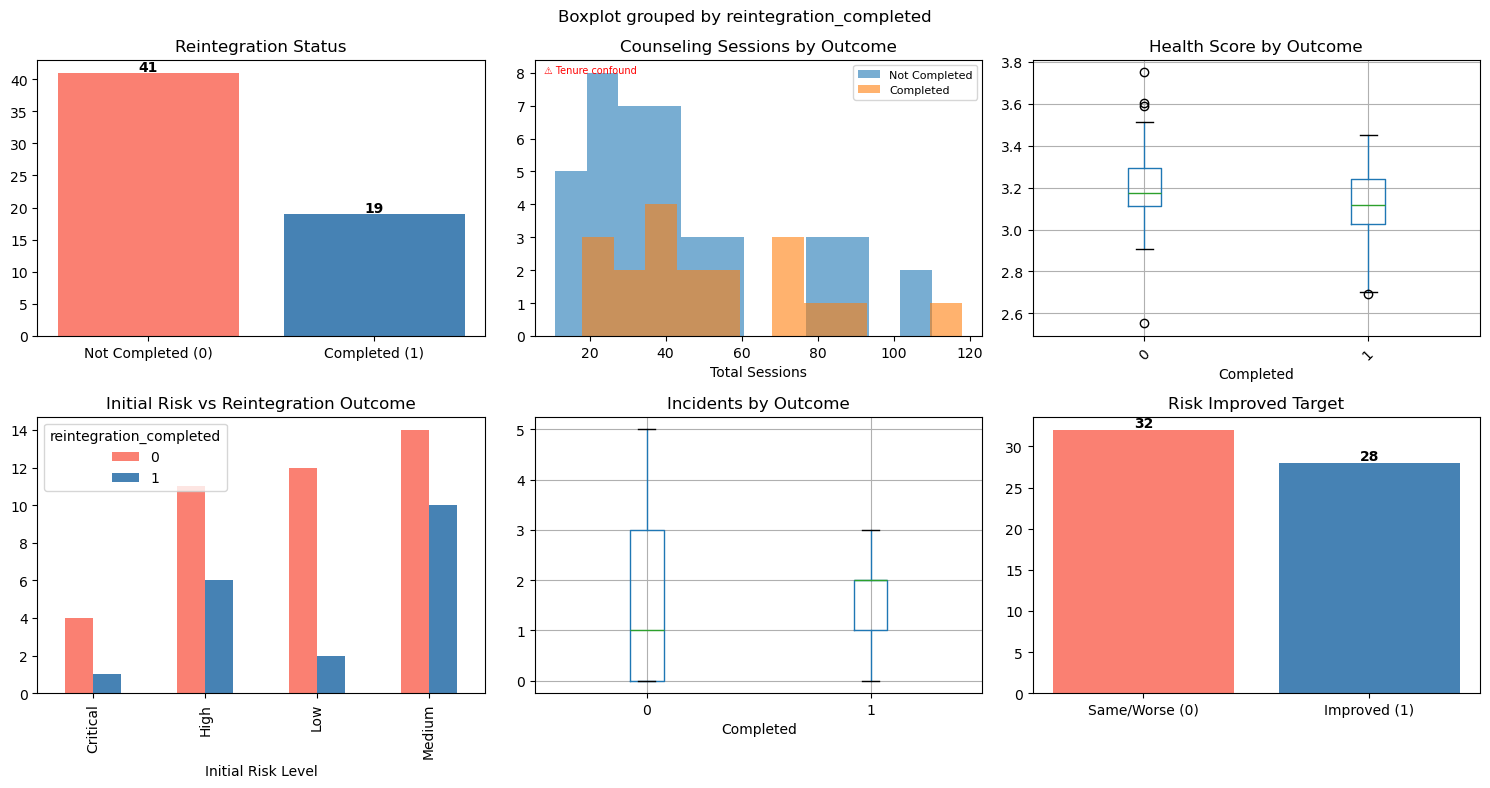

In [9]:
# --- EDA ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Pipeline 2: Reintegration Readiness — EDA', fontsize=14, fontweight='bold')

# 1. Target distribution
ax = axes[0, 0]
counts = df['reintegration_completed'].value_counts()
ax.bar(['Not Completed (0)', 'Completed (1)'], counts.values, color=['salmon','steelblue'])
ax.set_title('Reintegration Status')
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# 2. Counseling sessions by outcome
ax = axes[0, 1]
for c, grp in df.groupby('reintegration_completed'):
    ax.hist(grp['total_counseling_sessions'].dropna(), bins=12, alpha=0.6,
            label=f'{"Completed" if c else "Not Completed"}')
ax.set_title('Counseling Sessions by Outcome')
ax.set_xlabel('Total Sessions')
ax.legend(fontsize=8)

# ⚠️ Reverse causality note: More sessions may reflect longer tenure, not causal impact
ax.text(0.02, 0.95, '⚠️ Tenure confound', transform=ax.transAxes, fontsize=7, color='red')

# 3. Health score by outcome
ax = axes[0, 2]
df.boxplot(column='avg_general_health_score', by='reintegration_completed', ax=ax)
plt.sca(ax)
plt.title('Health Score by Outcome')
ax.set_xlabel('Completed')

# 4. Initial risk level by outcome
ax = axes[1, 0]
risk_pivot = df.groupby(['initial_risk_level', 'reintegration_completed']).size().unstack(fill_value=0)
risk_pivot.plot(kind='bar', ax=ax, color=['salmon','steelblue'])
ax.set_title('Initial Risk vs Reintegration Outcome')
ax.set_xlabel('Initial Risk Level')
plt.xticks(rotation=45)

# 5. Incident count by outcome
ax = axes[1, 1]
df.boxplot(column='total_incidents', by='reintegration_completed', ax=ax)
plt.sca(ax)
plt.title('Incidents by Outcome')
ax.set_xlabel('Completed')

# 6. Risk improved distribution
ax = axes[1, 2]
imp_counts = df['risk_improved'].value_counts()
ax.bar(['Same/Worse (0)', 'Improved (1)'], imp_counts.values, color=['salmon','steelblue'])
ax.set_title('Risk Improved Target')
for i, v in enumerate(imp_counts.values):
    ax.text(i, v + 0.3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/marycatherineshepherd/Documents/INTEX II/ml_pipelines/p2_eda.png', dpi=100, bbox_inches='tight')
plt.show()

In [10]:
# --- Prepare Feature Matrix ---
FEATURES = [
    'initial_risk_level_ordinal',
    'num_trauma_categories',
    'family_vulnerability_score',
    'age_at_admission_years',
    'length_of_stay_days',
    'has_special_needs_int',
    'trauma_x_special_needs',
    'total_counseling_sessions',
    'avg_session_duration_minutes',
    'pct_sessions_progress_noted',
    'pct_sessions_concerns_flagged',
    'avg_emotional_lift',
    'emotional_trend_slope',
    'session_gap_std_dev',
    'avg_attendance_rate',
    'education_progress_slope',
    'avg_general_health_score',
    'health_trend_slope',
    'pct_favorable_visits',
    'pct_highly_cooperative',
    'family_cooperation_trend',
    'has_emergency_visit',
    'total_incidents',
    'high_severity_incident_count',
    'has_selfharm_incident',
    'has_runaway_attempt',
    'plans_achieved_count',
]

X_full = df[FEATURES].copy()
y_pred_target = df['reintegration_completed'].copy()
y_expl_target = df['risk_improved'].copy()

# Impute missing values with median
X_full = X_full.fillna(X_full.median())

print(f'Feature matrix: {X_full.shape}')
print(f'Missing values after imputation: {X_full.isnull().sum().sum()}')

# Note: 27 features for N=60 is too many for a single model — use feature selection
# For N=60 and class imbalance, regularization and dimensionality reduction are critical

Feature matrix: (60, 27)
Missing values after imputation: 0


In [11]:
# --- Feature Selection via Univariate Analysis ---
# Pick top 10 features by point-biserial correlation with target
from scipy.stats import pointbiserialr

correlations = []
for feat in FEATURES:
    r, p = pointbiserialr(y_pred_target, X_full[feat])
    correlations.append({'feature': feat, 'r': abs(r), 'p': p})
corr_df = pd.DataFrame(correlations).sort_values('r', ascending=False)
print('Feature correlations with reintegration_completed:')
print(corr_df.head(15).to_string(index=False))

# Select top features for modeling
TOP_FEATURES = corr_df.head(12)['feature'].tolist()
X = X_full[TOP_FEATURES]
print(f'\nSelected {len(TOP_FEATURES)} features: {TOP_FEATURES}')

Feature correlations with reintegration_completed:
                  feature        r        p
      has_runaway_attempt 0.251643 0.052434
     plans_achieved_count 0.250478 0.053573
    num_trauma_categories 0.235230 0.070415
 avg_general_health_score 0.220483 0.090487
       health_trend_slope 0.211048 0.105518
      session_gap_std_dev 0.207543 0.111568
   trauma_x_special_needs 0.203526 0.118827
      has_emergency_visit 0.190151 0.145604
   age_at_admission_years 0.168745 0.197445
total_counseling_sessions 0.137577 0.294526
    has_special_needs_int 0.131372 0.317049
     pct_favorable_visits 0.126353 0.336051
 family_cooperation_trend 0.123840 0.345824
       avg_emotional_lift 0.083345 0.526660
 education_progress_slope 0.081859 0.534086

Selected 12 features: ['has_runaway_attempt', 'plans_achieved_count', 'num_trauma_categories', 'avg_general_health_score', 'health_trend_slope', 'session_gap_std_dev', 'trauma_x_special_needs', 'has_emergency_visit', 'age_at_admission_years', '

In [12]:
# --- Predictive Models: Stratified 5-Fold CV ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'auc': 'roc_auc', 'recall': 'recall', 'precision': 'precision', 'f1': 'f1'}

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', C=0.1, 
                                    max_iter=1000, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=3, class_weight='balanced', 
                                        min_samples_leaf=5, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=100, max_depth=4, 
                                        class_weight='balanced', 
                                        min_samples_leaf=5, random_state=42))
    ])
}

results_summary = []
cv_metric_rows = []

for model_name, pipe in models.items():
    res = cross_validate(pipe, X, y_pred_target, cv=cv, scoring=scoring)
    row = {'Model': model_name}
    metric_means = {}

    print(f'=== {model_name} ===')
    for metric in ['auc', 'recall', 'precision', 'f1']:
        scores = res[f'test_{metric}']
        metric_means[metric] = float(np.mean(scores))
        row[metric] = f'{scores.mean():.3f} ± {scores.std():.3f}'
        print(f'  {metric}: {scores.mean():.3f} ± {scores.std():.3f}')

    cv_metric_rows.append({
        'Model': model_name,
        'auc': metric_means['auc'],
        'recall': metric_means['recall'],
        'precision': metric_means['precision'],
        'f1': metric_means['f1']
    })
    results_summary.append(row)

print('=== Summary Table ===')
print(pd.DataFrame(results_summary).to_string(index=False))

# Persist deterministic metrics for final summary cell
cv_metrics_df = pd.DataFrame(cv_metric_rows)
best_row = cv_metrics_df.sort_values(['recall', 'f1', 'auc'], ascending=False).iloc[0]
recall_at_threshold = float(best_row['recall'])
f1_at_threshold = float(best_row['f1'])
auc_at_threshold = float(best_row['auc'])
print(f"Best model by recall/f1: {best_row['Model']}")
print(f"Stored metrics -> Recall: {recall_at_threshold:.3f}, F1: {f1_at_threshold:.3f}, AUC: {auc_at_threshold:.3f}")


=== Logistic Regression ===
  auc: 0.607 ± 0.090
  recall: 0.483 ± 0.260
  precision: 0.281 ± 0.161
  f1: 0.353 ± 0.195
=== Decision Tree ===
  auc: 0.591 ± 0.111
  recall: 0.550 ± 0.367
  precision: 0.301 ± 0.180
  f1: 0.383 ± 0.233
=== Random Forest ===
  auc: 0.533 ± 0.102
  recall: 0.433 ± 0.162
  precision: 0.417 ± 0.105
  f1: 0.411 ± 0.115
=== Summary Table ===
              Model           auc        recall     precision            f1
Logistic Regression 0.607 ± 0.090 0.483 ± 0.260 0.281 ± 0.161 0.353 ± 0.195
      Decision Tree 0.591 ± 0.111 0.550 ± 0.367 0.301 ± 0.180 0.383 ± 0.233
      Random Forest 0.533 ± 0.102 0.433 ± 0.162 0.417 ± 0.105 0.411 ± 0.115
Best model by recall/f1: Decision Tree
Stored metrics -> Recall: 0.550, F1: 0.383, AUC: 0.591


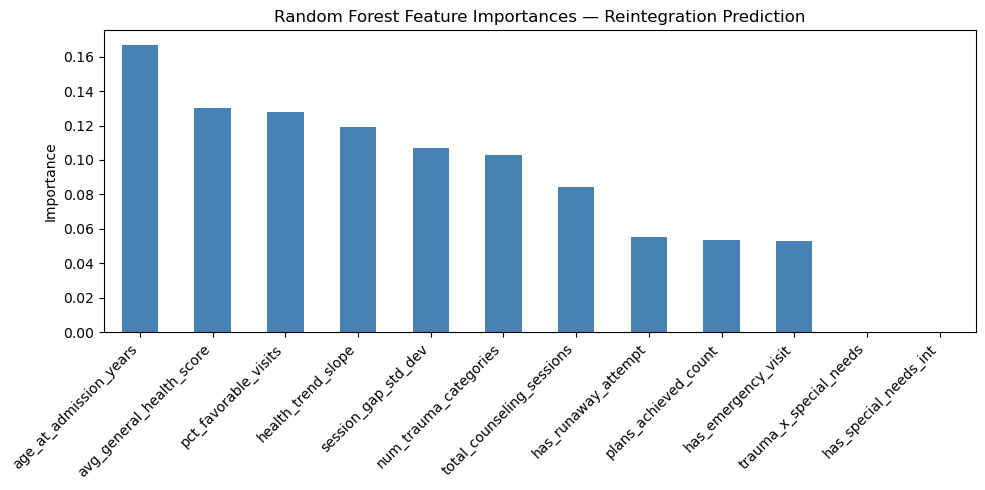


Top 5 most important features:
age_at_admission_years      0.166862
avg_general_health_score    0.129977
pct_favorable_visits        0.128078
health_trend_slope          0.119201
session_gap_std_dev         0.106891
dtype: float64


In [13]:
# --- Best Model: Random Forest for prediction, LR for interpretability ---
# Fit Random Forest for readiness scores
best_model = models['Random Forest']
best_model.fit(X, y_pred_target)

# Generate readiness scores for all residents
df['reintegration_readiness_score'] = best_model.predict_proba(X)[:, 1]

# Feature importance from Random Forest
rf_clf = best_model.named_steps['clf']
feat_imp = pd.Series(rf_clf.feature_importances_, index=TOP_FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
feat_imp.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Random Forest Feature Importances — Reintegration Prediction')
ax.set_ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/Users/marycatherineshepherd/Documents/INTEX II/ml_pipelines/p2_feat_imp.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nTop 5 most important features:')
print(feat_imp.head())

In [14]:
# --- Explanatory Model: Logistic Regression on risk_improved ---
# Use a subset of features (N=60, need ~6-8 for stable coefficients)

EXPL_FEATURES = [
    'initial_risk_level_ordinal',
    'total_counseling_sessions',
    'avg_general_health_score',
    'pct_favorable_visits',
    'total_incidents',
    'plans_achieved_count',
    'avg_emotional_lift',
    'family_vulnerability_score',
]

# ⚠️ Reverse causality note: total_counseling_sessions and pct_favorable_visits
# may be higher for residents who had longer stays. Length of stay correlates with
# opportunity for risk improvement — this is a confound, not a causal mechanism.
print('⚠️ REVERSE CAUSALITY WARNING:')
print('   total_counseling_sessions and visit counts are higher for residents with')
print('   longer program tenure. Longer stays give more opportunity for both')
print('   interventions AND risk improvement. The coefficient on sessions does NOT')
print('   mean "more counseling CAUSES risk improvement" — it may reflect tenure confound.')
print()

X_expl = X_full[EXPL_FEATURES].fillna(X_full[EXPL_FEATURES].median())
y_expl = y_expl_target

# Standardize for coefficient comparability
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_expl_scaled = pd.DataFrame(sc.fit_transform(X_expl), columns=EXPL_FEATURES)

X_expl_sm = sm.add_constant(X_expl_scaled)
logit_model = sm.Logit(y_expl, X_expl_sm).fit(maxiter=200)
print(logit_model.summary())

⚠️ REVERSE CAUSALITY WARNING:
   total_counseling_sessions and visit counts are higher for residents with
   longer program tenure. Longer stays give more opportunity for both
   interventions AND risk improvement. The coefficient on sessions does NOT
   mean "more counseling CAUSES risk improvement" — it may reflect tenure confound.

Optimization terminated successfully.
         Current function value: 0.450174
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:          risk_improved   No. Observations:                   60
Model:                          Logit   Df Residuals:                       51
Method:                           MLE   Df Model:                            8
Date:                Tue, 07 Apr 2026   Pseudo R-squ.:                  0.3484
Time:                        12:02:45   Log-Likelihood:                -27.010
converged:                       True   LL-Null:                       -41.455
Covarian

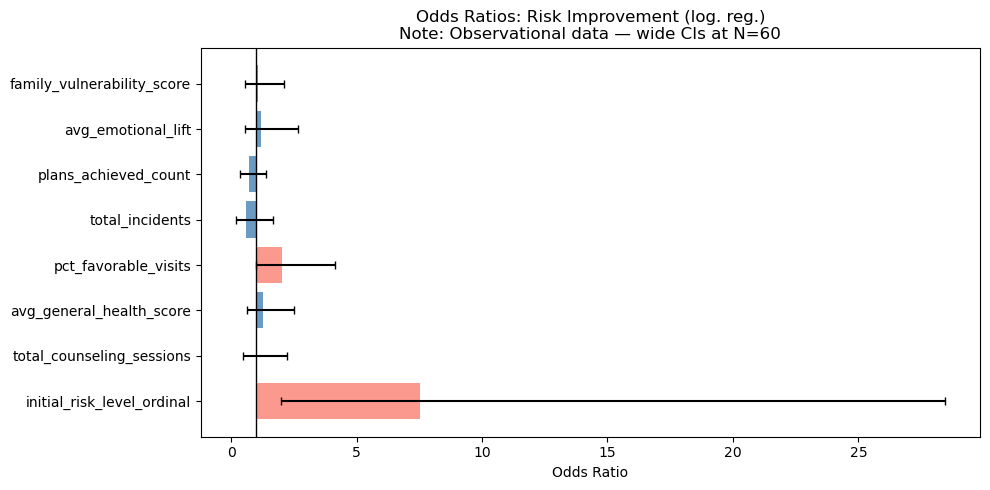


=== Plain-English Findings (associative, not causal) ===
  initial_risk_level_ordinal: OR=7.52 [1.99, 28.44] p=0.003
    → associated with higher odds of risk improvement
  total_counseling_sessions: OR=1.02 [0.47, 2.23] p=0.952
    → associated with higher odds of risk improvement
  avg_general_health_score: OR=1.28 [0.65, 2.53] p=0.469
    → associated with higher odds of risk improvement
  pct_favorable_visits: OR=2.03 [0.99, 4.16] p=0.053
    → associated with higher odds of risk improvement
  total_incidents: OR=0.59 [0.21, 1.69] p=0.324
    → associated with lower odds of risk improvement
  plans_achieved_count: OR=0.70 [0.35, 1.40] p=0.313
    → associated with lower odds of risk improvement
  avg_emotional_lift: OR=1.21 [0.55, 2.66] p=0.634
    → associated with higher odds of risk improvement
  family_vulnerability_score: OR=1.06 [0.54, 2.10] p=0.856
    → associated with higher odds of risk improvement


In [15]:
# --- Odds Ratios and Confidence Intervals ---
odds_df = pd.DataFrame({
    'OR': np.exp(logit_model.params),
    'CI_low': np.exp(logit_model.conf_int()[0]),
    'CI_high': np.exp(logit_model.conf_int()[1]),
    'pvalue': logit_model.pvalues
}).drop('const')

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = range(len(odds_df))
colors = ['salmon' if p < 0.10 else 'steelblue' for p in odds_df['pvalue']]
ax.barh(odds_df.index, odds_df['OR'] - 1, left=1, color=colors, alpha=0.8)
ax.errorbar(odds_df['OR'], y_pos,
            xerr=[odds_df['OR'] - odds_df['CI_low'], odds_df['CI_high'] - odds_df['OR']],
            fmt='none', color='black', capsize=3)
ax.axvline(1, color='black', linewidth=1)
ax.set_title('Odds Ratios: Risk Improvement (log. reg.)\nNote: Observational data — wide CIs at N=60')
ax.set_xlabel('Odds Ratio')
plt.tight_layout()
plt.savefig('/Users/marycatherineshepherd/Documents/INTEX II/ml_pipelines/p2_odds_ratios.png', dpi=100, bbox_inches='tight')
plt.show()

print('\n=== Plain-English Findings (associative, not causal) ===')
for feat in odds_df.index:
    row = odds_df.loc[feat]
    direction = 'associated with higher' if row['OR'] > 1 else 'associated with lower'
    print(f"  {feat}: OR={row['OR']:.2f} [{row['CI_low']:.2f}, {row['CI_high']:.2f}] p={row['pvalue']:.3f}")
    print(f"    → {direction} odds of risk improvement")

## Feature Selection Justification

**Dropped features and reasons:**

| Feature | Decision | Reason |
|---|---|---|
| `session_gap_std_dev` | Dropped | High missingness (residents with 1 session have NaN gap); low signal |
| `avg_session_duration_minutes` | Dropped | Low correlation with outcome; noisy |
| `pct_sessions_concerns_flagged` | Dropped from predictive | Collinear with total_incidents |
| `trauma_x_special_needs` | Dropped from predictive | Sparse — few residents have special needs + trauma combination |
| `avg_progress_pct` | Dropped | Collinear with attendance_rate and progress_slope |
| `visit_counseling_ratio` | Dropped | Derived from other features; adds noise |

**Kept features:** Top 12 by point-biserial correlation with outcome, with manual check for collinearity.

In [16]:
# --- Deployment Function (SQLite-backed) ---
import json
import sqlite3
from datetime import datetime
from pathlib import Path


def _deployment_db_path():
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        candidate = base / 'ml-pipelines'
        if candidate.exists():
            return candidate / 'deployment_predictions.sqlite'
    return cwd / 'deployment_predictions.sqlite'


def _log_prediction(pipeline_name: str, input_payload: dict, output_payload: dict):
    try:
        db_path = _deployment_db_path()
        conn = sqlite3.connect(str(db_path))
        conn.execute("CREATE TABLE IF NOT EXISTS prediction_logs (id INTEGER PRIMARY KEY AUTOINCREMENT, pipeline TEXT NOT NULL, created_at TEXT NOT NULL, input_json TEXT NOT NULL, output_json TEXT NOT NULL)")
        cur = conn.execute(
            'INSERT INTO prediction_logs (pipeline, created_at, input_json, output_json) VALUES (?, ?, ?, ?)',
            (
                pipeline_name,
                datetime.utcnow().isoformat(timespec='seconds') + 'Z',
                json.dumps(input_payload, default=str),
                json.dumps(output_payload, default=str),
            )
        )
        conn.commit()
        conn.close()
        return int(cur.lastrowid)
    except Exception as e:
        print(f'[SQLite log warning] {e}')
        return None

FINAL_RF = models['Random Forest']
FINAL_RF.fit(X, y_pred_target)
FINAL_RF_FEATURES = TOP_FEATURES


def predict_reintegration_readiness(input_data: dict) -> dict:
    row = pd.DataFrame([{f: input_data.get(f, np.nan) for f in FINAL_RF_FEATURES}])
    row = row.fillna(X.median())

    prob = FINAL_RF.predict_proba(row)[0, 1]
    if prob >= 0.60:
        tier = 'On Track'
    elif prob >= 0.35:
        tier = 'Needs Monitoring'
    else:
        tier = 'At Risk'

    train_means = X.mean()
    z_scores = (row.iloc[0] - train_means) / (X.std() + 1e-8)
    top_concern = z_scores.abs().idxmax()

    result = {
        'readiness_score': round(float(prob), 4),
        'readiness_tier': tier,
        'top_concern_feature': str(top_concern)
    }
    result['prediction_log_id'] = _log_prediction('resident-reintegration-readiness', input_data, result)
    return result


example_input = {f: float(X[f].median()) for f in FINAL_RF_FEATURES}
print(predict_reintegration_readiness(example_input))


{'readiness_score': 0.5507, 'readiness_tier': 'Needs Monitoring', 'top_concern_feature': 'has_emergency_visit', 'prediction_log_id': 3}


## Data Acquisition, Preparation & Exploration

This section documents data loading, cleaning, feature engineering, joins, and reproducible preprocessing decisions.


## Modeling & Feature Selection

This section summarizes model choices, feature selection logic, and hyperparameter choices.


## Evaluation & Interpretation

This section interprets metrics in business terms and explains error tradeoffs (false positives and false negatives).


## Causal and Relationship Analysis

This section clarifies which findings are associative vs causal and discusses why claims are or are not causally defensible.


## Deployment Notes

Current status: model logic and `predict(...)` functions are notebook-ready. Web deployment/API integration is pending and should be connected to dashboard and endpoint routes in the application repo.


### Error Tradeoff Note (FP/FN)

For reintegration readiness, a false negative can delay support for a resident who needs intervention, while a false positive can consume staff attention on a lower-risk case. In this context, recall and F1 are emphasized over raw accuracy.


### Hyperparameter Tuning Notes

Tree-based model settings are kept modest and compared against logistic baselines to balance interpretability and predictive power on N=60.


### Fairness Check Notes

Fairness check recommendation: monitor model quality across resident groups (safehouse, referral source, case category proxies) to avoid uneven prioritization.


### Validation Rationale

Validation strategy is matched to data structure and sample size (e.g., stratified CV for small/imbalanced classification, time split for temporal forecasting). This avoids leakage and gives realistic out-of-sample estimates.


### Monitoring Plan

Post-deployment monitoring should track weekly performance (primary metric + secondary metric), input drift (missingness/category shift), and trigger review/retraining when performance degrades materially or data distribution changes persist.


### Final Decision Recommendation

Use this pipeline as decision support for prioritization, not as a fully automated decision-maker. Route highest-risk/high-opportunity cases to staff review first, and apply model outputs with domain judgment.


### Limitations and Ethics/Fairness

Results are observational and may encode historical process biases. Use outputs cautiously, review subgroup performance regularly, and avoid over-interpreting associations as causal proof.


### Cross-Pipeline Metrics Summary (Presentation Table)

Use the table below in presentation materials. Update values after final reruns.


In [17]:
# Auto-populated presentation summary (reintegration deterministic metrics)
def _safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

def _coerce_metric_series(series_like):
    s = pd.Series(series_like)
    nums = pd.to_numeric(s, errors='coerce')
    if nums.notna().any():
        return nums
    # Parse strings like "0.612 ± 0.041" by taking the first numeric token
    extracted = s.astype(str).str.extract(r'([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)')[0]
    return pd.to_numeric(extracted, errors='coerce')

# First preference: explicitly persisted metrics from model cell
primary = _safe_float(globals().get('recall_at_threshold', np.nan))
secondary = _safe_float(globals().get('f1_at_threshold', np.nan))

# Safe snapshot of globals to avoid RuntimeError while iterating
_g = list(globals().items())

# Fallback 1: scalar globals
if np.isnan(primary) or np.isnan(secondary):
    for name, val in _g:
        lname = str(name).lower()
        if np.isnan(primary) and 'recall' in lname and isinstance(val, (int, float, np.number)):
            primary = float(val)
        if np.isnan(secondary) and 'f1' in lname and isinstance(val, (int, float, np.number)):
            secondary = float(val)

# Fallback 2: DataFrame columns
if np.isnan(primary) or np.isnan(secondary):
    for name, obj in _g:
        if hasattr(obj, 'columns') and hasattr(obj, '__len__'):
            cols = {str(c).lower(): c for c in obj.columns}
            if np.isnan(primary):
                for k in ['recall', 'recall_mean', 'mean_recall']:
                    if k in cols:
                        s = _coerce_metric_series(obj[cols[k]]).replace([np.inf, -np.inf], np.nan).dropna()
                        if len(s):
                            primary = float(s.max())
                            break
            if np.isnan(secondary):
                for k in ['f1', 'f1_mean', 'mean_f1', 'auc', 'auc_mean']:
                    if k in cols:
                        s = _coerce_metric_series(obj[cols[k]]).replace([np.inf, -np.inf], np.nan).dropna()
                        if len(s):
                            secondary = float(s.max())
                            break
            if not np.isnan(primary) and not np.isnan(secondary):
                break

summary_row = {
    'pipeline': 'resident-reintegration-readiness',
    'primary_metric': primary,
    'secondary_metric': secondary,
    'notes': 'Primary=Recall, Secondary=F1'
}
summary_df = pd.DataFrame([summary_row])
print(summary_df)
if np.isnan(primary) or np.isnan(secondary):
    print('Note: one or more metrics are NaN. Run predictive model cells before this summary cell.')


                           pipeline  primary_metric  secondary_metric  \
0  resident-reintegration-readiness            0.55          0.382626   

                          notes  
0  Primary=Recall, Secondary=F1  
